# Dot Plot Analysis: Per-Mode and Combined Visualizations

Dot plot visualizations of drum and foot onset phase distributions, organized by individual dance modes (group, individual, audience) and combined across all modes.

**Features**: Drum onset plots (Dun, J1, J2), foot onset plots (left/right), mode-specific and combined analyses, KDE overlays, phase-aligned to musical cycles (0-400 metric units), stacked visualizations with subdivision markers, batch processing.

**Data**: Virtual cycle CSVs (`data/virtual_cycles/`), drum onset CSVs (`data/drum_onsets/`), foot onset CSVs (`data/logs_v*/.../onset_info/`), dance mode time segments (`data/dance_modes_ts/`), selected piece list (`data/selected_piece_list.pkl`).

**Output**: Per-mode plots (PNG) organized by mode, combined plots aggregating all modes, stacked scatter plots with KDE overlays. Saved to `output_dot_plots/` with subdirectories for drum and dance analyses.

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# from utils_subdivision.gen_distribution_single_plots import analyze_phases
# from utils_subdivision.gen_distribution_subplot import analyze_single_type    # plot_combined_results
# from utils_subdivision.gen_distribution_merged_plot import plot_merged
from utils_dot_plot.drum_single import analyze_phases
# from utils_dot_plot.drum_merged import plot_merged_per_mode

from utils_subdivision.gen_distribution_subplot import analyze_single_type
from utils_dot_plot.kinematic_dot_plot import *
from utils_dot_plot.drum_merged import *


base_output_dir = "output_dot_plots"

# Generate Dance dot plot by Group, Individual or Audience

In [ ]:
# m_idx = 0
modes = ["group", "individual", "audience"]
# dance_mode = modes[m_idx]

with open('data/selected_piece_list.pkl', 'rb') as f:
    piece_list = pickle.load(f)
    
for dance_mode in modes:
    print(dance_mode)
    for file_name in piece_list:
        print(file_name)
        cycles_csv_path = f"data/virtual_cycles/{file_name}_C.csv"
        
        dmode_path = f"data/dance_modes_ts/{file_name}_{dance_mode}.pkl"
        if not os.path.exists(dmode_path):
            continue
        
        left_onset_path = f"data/logs_v4_0.007_foot_jun3/{file_name}_T/onset_info/{file_name}_T_left_foot_onsets.csv"
        right_onset_path = f"data/logs_v4_0.007_foot_jun3/{file_name}_T/onset_info/{file_name}_T_right_foot_onsets.csv"
        
        left_onsets = pd.read_csv(left_onset_path)["time_sec"].values
        right_onsets = pd.read_csv(right_onset_path)["time_sec"].values
        
        if os.path.exists(dmode_path):
            with open(dmode_path, "rb") as f:
                dance_mode_time_segments = pickle.load(f)
                
            fig, ax, _ = plot_foot_onsets_stacked(
                file_name=file_name,
                dance_mode=dance_mode,
                cycles_csv_path=cycles_csv_path,
                left_onsets=left_onsets,
                right_onsets=right_onsets,
                dance_mode_time_segments=dance_mode_time_segments,
                figsize=(10, 3),
                dpi=300,
                use_window=True,
                legend_flag=False
            )
            
            save_dir = os.path.join(base_output_dir, "dance", dance_mode)
            os.makedirs(save_dir, exist_ok=True)
            
            save_path = os.path.join(save_dir, f"{file_name}_{dance_mode}_merged.png")
            plt.savefig(save_path, bbox_inches='tight', dpi=300)  # Add bbox_inches='tight' to prevent label clipping
            plt.close()
    # break

### Merged Drum Dot Plot - All modes combined

In [ ]:
# Load the piece list
with open('data/selected_piece_list.pkl', 'rb') as f:
    piece_list = pickle.load(f)

# Loop over each file in the piece list
for file_name in piece_list:
    print(f"Processing {file_name}...")
    
    # Define paths
    cycles_csv_path = f"data/virtual_cycles/{file_name}_C.csv"
    onsets_csv_path = f"data/drum_onsets/{file_name}.csv"
    
    # Check if required files exist
    if not (os.path.exists(cycles_csv_path) and os.path.exists(onsets_csv_path)):
        print(f"Skipping {file_name} - missing required files")
        continue
    
    # Load all modes' time segments
    dance_mode_time_segments_all = {}
    for mode in ["group", "individual", "audience"]:
        dmode_path = f"data/dance_modes_ts/{file_name}_{mode}.pkl"
        if os.path.exists(dmode_path):
            with open(dmode_path, "rb") as f:
                dance_mode_time_segments_all[mode] = pickle.load(f)
    
    # Skip if no mode data available
    if not dance_mode_time_segments_all:
        print(f"Skipping {file_name} - no mode data available")
        continue
    
    # try:
    # Call the modified function
    fig, ax, drum_phases_kde = drum_plot_merged_stacked_all_modes(
        file_name=file_name,
        cycles_csv_path=cycles_csv_path,
        onsets_csv_path=onsets_csv_path,
        dance_mode_time_segments_all=dance_mode_time_segments_all,
        figsize=(10, 3),
        dpi=300,
        use_window=True,
        legend_flag=False
    )
    
    # Save the figure
    save_dir = os.path.join(base_output_dir, "drum_merged", "all_modes")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"{file_name}_all_modes_merged.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.close()
    
    print(f"Successfully processed {file_name}")
        
    # except Exception as e:
    #     print(f"Error processing {file_name}: {str(e)}")
    #     continue

print("Processing complete!")

## Dance dot plot - All modes combined

Processing BKO_E1_D1_01_Suku...
Successfully processed BKO_E1_D1_01_Suku


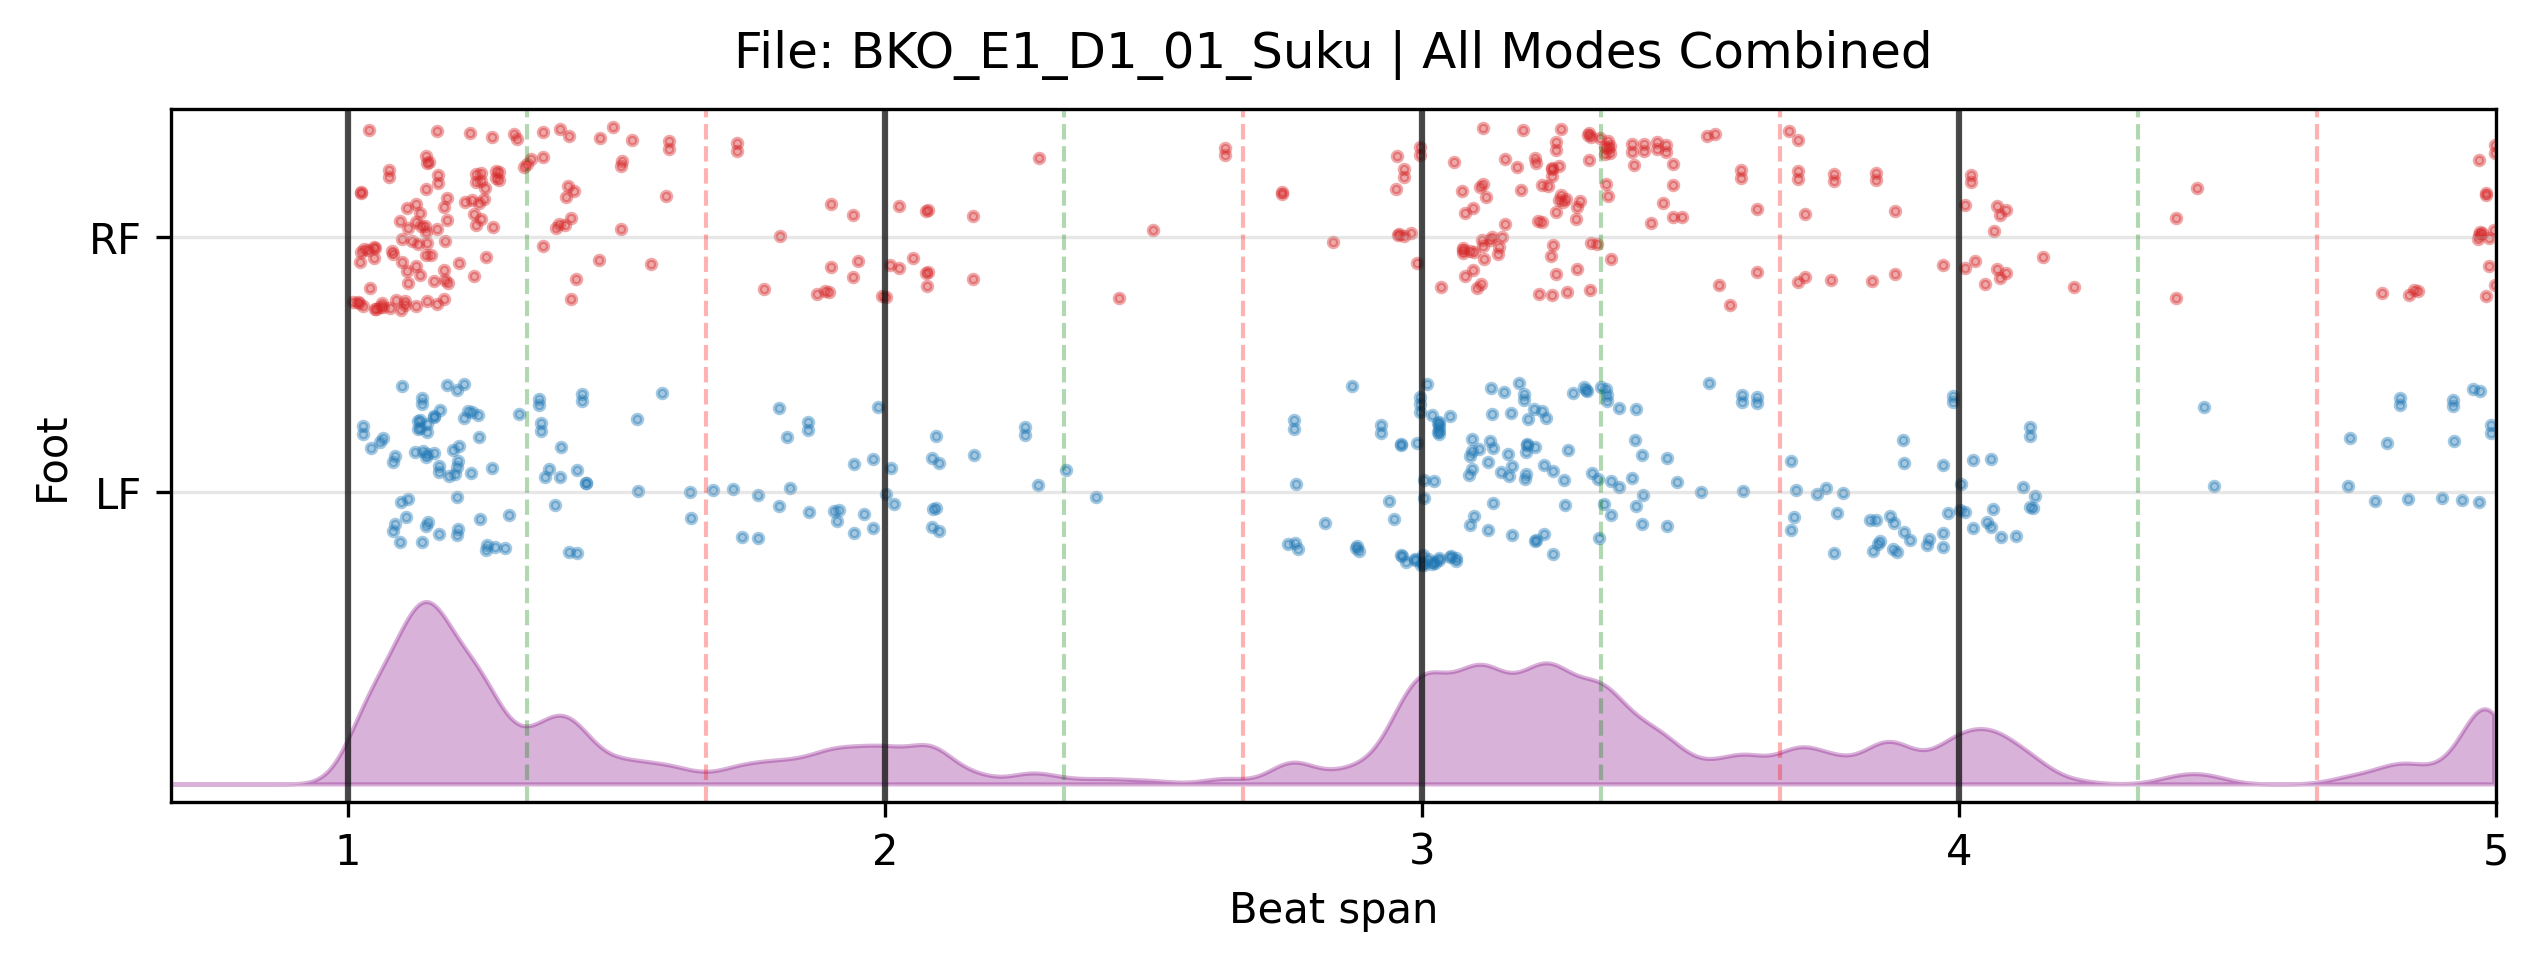

Processing complete!


In [2]:
# Load the piece list
with open('data/selected_piece_list.pkl', 'rb') as f:
    piece_list = pickle.load(f)

# Loop over each file in the piece list
for file_name in piece_list:
    print(f"Processing {file_name}...")
    
    # Define paths
    cycles_csv_path = f"data/virtual_cycles/{file_name}_C.csv"
    left_onset_path = f"data/logs_v4_0.007_foot_jun3/{file_name}_T/onset_info/{file_name}_T_left_foot_onsets.csv"
    right_onset_path = f"data/logs_v4_0.007_foot_jun3/{file_name}_T/onset_info/{file_name}_T_right_foot_onsets.csv"
    
    # Check if required files exist
    if not (os.path.exists(cycles_csv_path) and 
            os.path.exists(left_onset_path) and 
            os.path.exists(right_onset_path)):
        print(f"Skipping {file_name} - missing required files")
        continue
    
    # Load all modes' time segments
    dance_mode_time_segments_all = {}
    for mode in ["group", "individual", "audience"]:
        dmode_path = f"data/dance_modes_ts/{file_name}_{mode}.pkl"
        if os.path.exists(dmode_path):
            with open(dmode_path, "rb") as f:
                dance_mode_time_segments_all[mode] = pickle.load(f)
    
    # Skip if no mode data available
    if not dance_mode_time_segments_all:
        print(f"Skipping {file_name} - no mode data available")
        continue
    

    # Call the modified function
    fig, ax, foot_phases_kde = plot_foot_onsets_stacked_all_modes(
        file_name=file_name,
        cycles_csv_path=cycles_csv_path,
        left_onset_path=left_onset_path,
        right_onset_path=right_onset_path,
        dance_mode_time_segments_all=dance_mode_time_segments_all,
        figsize=(10, 3),
        dpi=300,
        use_window=True,
        legend_flag=False
    )
    
    # Save the figure
    save_dir = os.path.join(base_output_dir, "dance", "all_modes")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"{file_name}_all_modes_merged.png")
    # plt.savefig(save_path, bbox_inches='tight', dpi=300)
    # plt.close()
    
    print(f"Successfully processed {file_name}")
    
    plt.show(fig)
    break

print("Processing complete!")